In [22]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import torch
from torch_geometric.data import Data
print(os.getpid())

2778664


In [23]:
folder_path = "Data"

sequence=[]
distance_map=[]
dca=[]
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence.append(loaded['sequence'])
        distance_map.append(loaded['distance_map'])
        dca.append(loaded['dca'])

In [24]:
def contact_from_distance(distance_map, threshold=8.0):
    contact_map = (distance_map < threshold).astype(int)
    return contact_map  


def top_k_mask(matrix, k):
    n = matrix.shape[0]

    # Get upper triangle indices (excluding diagonal)
    triu_indices = np.triu_indices(n, k=1)

    # Extract corresponding values
    values = matrix[triu_indices]

    # Get indices of top-k values
    top_k_idx = np.argpartition(values, -k)[-k:]

    # Create empty mask
    mask = np.zeros_like(matrix, dtype=int)

    # Map back to matrix indices
    rows = triu_indices[0][top_k_idx]
    cols = triu_indices[1][top_k_idx]

    # Set both (i,j) and (j,i) = 1 (since symmetric)
    mask[rows, cols] = 1
    mask[cols, rows] = 1

    return mask

In [25]:
stats=np.zeros((300,3))


for i in range(len(sequence)):
    seq=sequence[i]
    dist=distance_map[i]
    dca_map=dca[i]

    contact_map = contact_from_distance(dist, threshold=8.0)
    isfinite = np.isfinite(dist)

    k = 5*len(seq)  
    binary_map = top_k_mask(dca_map, k)

    n = binary_map.shape[0]

    for i in range(n):
        for j in range(i+1, n):  # upper triangle only

            if isfinite[i][j]:

                d = int(dist[i, j])
                stats[d, 2] += 1  # total pairs at distance d

                if binary_map[i, j]==1:

                    if contact_map[i, j]==1:
                        #true positives
                        stats[d, 0] += 1

                    elif contact_map[i, j]==0:
                        #false positives
                        stats[d, 1] += 1
tp = stats[:, 0]
fp = stats[:, 1]
total_seen = stats[:, 2]
distances = np.arange(len(stats))
total_percentage = np.where(total_seen > 0, (tp + fp)/ total_seen , 0)
precision = np.where((tp + fp) > 0, tp / (tp + fp), 0)

/tmp/ipykernel_2778664/2004208958.py:38: RuntimeWarning: invalid value encountered in divide
  total_percentage = np.where(total_seen > 0, (tp + fp)/ total_seen , 0)
/tmp/ipykernel_2778664/2004208958.py:39: RuntimeWarning: invalid value encountered in divide
  precision = np.where((tp + fp) > 0, tp / (tp + fp), 0)


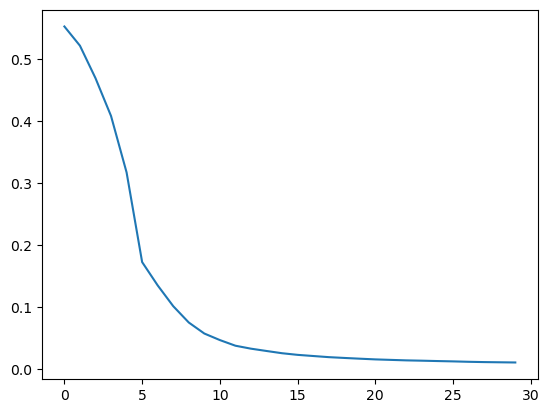

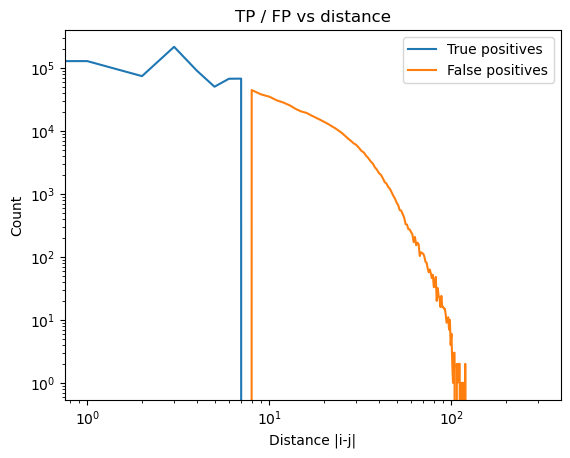

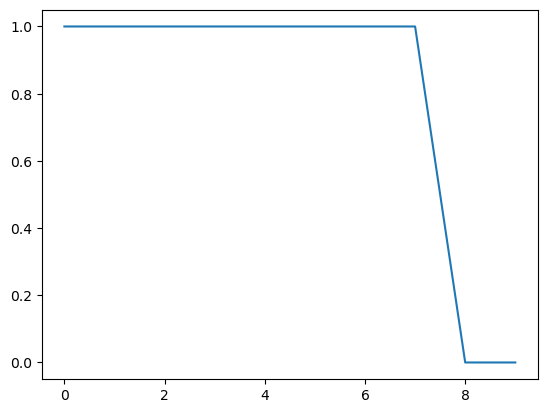

In [27]:
import matplotlib.pyplot as plt
plt.plot(distances[:30], total_percentage[:30], label="Percentage of contacts")
plt.show()


plt.loglog(distances, tp, label="True positives")
plt.loglog(distances, fp, label="False positives")

plt.xlabel("Distance |i-j|")
plt.ylabel("Count")
plt.title("TP / FP vs distance")
plt.legend()
plt.show()

import matplotlib.pyplot as plt
plt.plot(distances[:10], precision[:10], label="Percentage of contacts")
plt.show()

In [30]:
import numpy as np

def sample_noisy_contact_map_from_distance(
    distance_map,
    p_detect_by_r,
    K,
    threshold=8.0,
    seed=None,
):
    """
    Generate a noisy contact map using detection probabilities vs real distance.

    Parameters
    ----------
    distance_map : (L, L) array
        Real-valued distance matrix.
    p_detect_by_r : array-like
        p_detect_by_r[r] = probability of predicting a contact at distance r
        (r is assumed to be int(distance)).
    K : int
        Total number of predicted contacts (e.g. 5 * L).
    threshold : float
        Distance threshold separating true (<= threshold) and false (> threshold).
    seed : int or None

    Returns
    -------
    new_map : (L, L) int8 array
    stats : dict
        Contains counts of true/false contacts.
    """
    rng = np.random.default_rng(seed)

    D = np.asarray(distance_map)
    L = D.shape[0]

    # --- consider only upper triangle (i < j)
    i, j = np.triu_indices(L, k=1)

    dvals = D[i, j]
    valid = np.isfinite(dvals)

    i = i[valid]
    j = j[valid]
    dvals = dvals[valid]

    # --- convert distances to integer bins
    r = np.floor(dvals).astype(int)
    r = np.clip(r, 0, len(p_detect_by_r) - 1)

    # --- weights from empirical detection probability
    w = p_detect_by_r[r].astype(float)

    # avoid degenerate case
    if np.all(w == 0):
        raise ValueError("All detection probabilities are zero.")

    # --- split into true / false according to threshold
    true_mask = dvals <= threshold
    false_mask = dvals > threshold

    # weights per group
    w_true = w[true_mask]
    w_false = w[false_mask]

    # --- total weight
    W_true = w_true.sum()
    W_false = w_false.sum()
    W_total = W_true + W_false

    if W_total == 0:
        raise ValueError("Total weight is zero.")

    # --- allocate number of contacts
    K_true = int(round(K * W_true / W_total))
    K_false = K - K_true

    # --- indices
    true_i, true_j = i[true_mask], j[true_mask]
    false_i, false_j = i[false_mask], j[false_mask]

    # --- safety checks
    K_true = min(K_true, len(true_i))
    K_false = min(K_false, len(false_i))

    # --- probabilities within each group
    if len(w_true) > 0:
        p_true = w_true / w_true.sum()
        idx_true = rng.choice(len(true_i), size=K_true, replace=False, p=p_true)
    else:
        idx_true = np.array([], dtype=int)

    if len(w_false) > 0:
        p_false = w_false / w_false.sum()
        idx_false = rng.choice(len(false_i), size=K_false, replace=False, p=p_false)
    else:
        idx_false = np.array([], dtype=int)

    # --- build output map
    new_map = np.zeros((L, L), dtype=np.int8)

    # true contacts
    ti = true_i[idx_true]
    tj = true_j[idx_true]
    new_map[ti, tj] = 1
    new_map[tj, ti] = 1

    # false contacts
    fi = false_i[idx_false]
    fj = false_j[idx_false]
    new_map[fi, fj] = 1
    new_map[fj, fi] = 1

    stats = {
        "K_total": K,
        "K_true": len(idx_true),
        "K_false": len(idx_false),
        "fraction_true": len(idx_true) / K if K > 0 else 0.0,
    }

    return new_map, stats

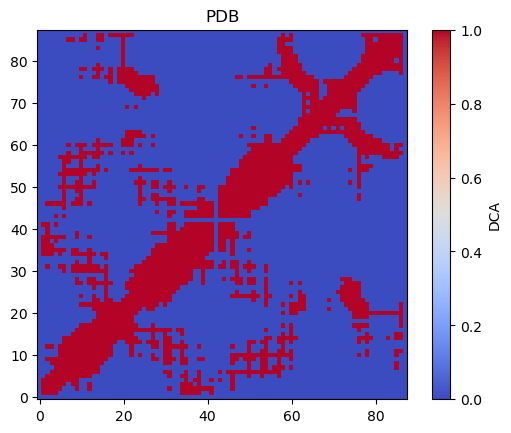

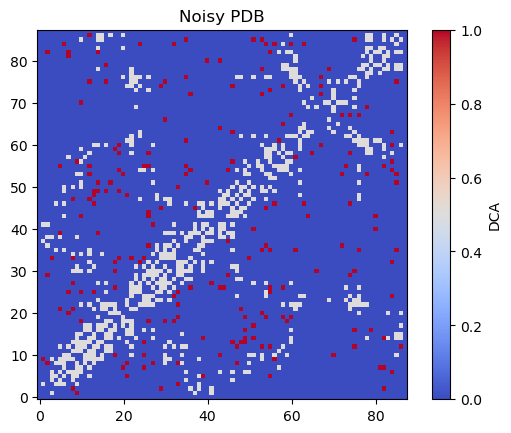

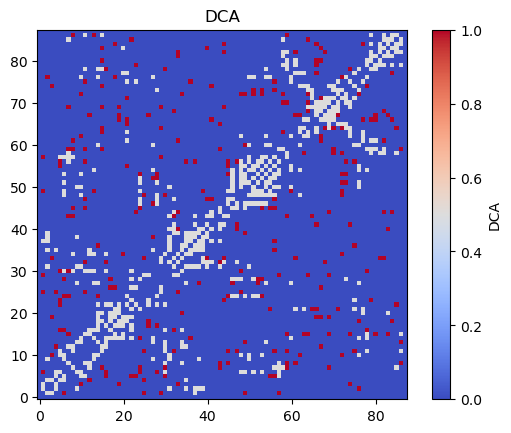

In [37]:
index=100
L = distance_map[index].shape[0]
K = 5 * L

p_detect_by_r = total_percentage
new_map, stats = sample_noisy_contact_map_from_distance(distance_map[index],p_detect_by_r,K,threshold=8.0,seed=1)


contact_map=contact_from_distance(distance_map[index])
isfinite = np.isfinite(distance_map[index])
plt.figure()
plt.imshow(contact_map,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA")
plt.title("PDB")
plt.show()

true_positives = (new_map == 1) & (contact_map == 1)
false_positives = (new_map == 1) & (contact_map== 0)

true_positives = true_positives.astype(float)
false_positives = false_positives.astype(float)

result= np.zeros_like(true_positives)
for i in range(len(true_positives)):
    for j in range(len(true_positives)):
        if true_positives[i][j] == 1 and isfinite[i][j]:
            result[i][j] = 0.5
        elif false_positives[i][j] == 1 and isfinite[i][j]:
            result[i][j] = 1.0
        else:
            result[i][j] = 0.0

plt.figure()
plt.imshow(result,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA")
plt.title("Noisy PDB")
plt.show()

binary_map = top_k_mask(dca[index], 5 * L)

true_positives = (binary_map == 1) & (contact_map == 1)
false_positives = (binary_map == 1) & (contact_map== 0)

true_positives = true_positives.astype(float)
false_positives = false_positives.astype(float)

result= np.zeros_like(true_positives)
for i in range(len(true_positives)):
    for j in range(len(true_positives)):
        if true_positives[i][j] == 1 and isfinite[i][j]:
            result[i][j] = 0.5
        elif false_positives[i][j] == 1 and isfinite[i][j]:
            result[i][j] = 1.0
        else:
            result[i][j] = 0.0

plt.figure()
plt.imshow(result,cmap='coolwarm', origin='lower')
#plt.imshow(false_positives,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="DCA")
plt.title("DCA")
plt.show()